🚀 Day 33: Handling Imbalanced Data in Machine Learning

---

## Objectives:

- Understand the challenges posed by **imbalanced datasets**.
- Learn different techniques to handle class imbalance:
  - **Resampling methods** (Oversampling and Undersampling)
  - **Synthetic Minority Over-sampling Technique (SMOTE)**
  - **Weighted Loss Functions**
- Apply these techniques to a real-world dataset.
- Improve model performance on imbalanced data.
- Use robust visualizations to compare model results.

---

## 1. Introduction to Imbalanced Data

### 1.1 What is Imbalanced Data?

In classification problems, **imbalanced data** refers to datasets where one class significantly outnumbers the other. This imbalance can lead to biased models that favor the majority class while ignoring the minority class.

### 1.2 Challenges with Imbalanced Data

- Standard classifiers tend to predict the majority class more often.
- **Accuracy can be misleading**, as predicting the dominant class might still give high accuracy.
- Minority class detection is crucial in applications like **fraud detection, medical diagnosis, and spam filtering**.

### 1.3 Techniques to Handle Imbalanced Data

1. **Resampling Methods**:
   - **Oversampling**: Increase the minority class instances.
   - **Undersampling**: Reduce the majority class instances.
2. **Synthetic Minority Over-sampling Technique (SMOTE)**: Generate synthetic samples for the minority class.
3. **Weighted Loss Functions**: Assign higher penalties to misclassified minority class instances.

---

## 2. Dataset Overview

We'll use the **Credit Card Fraud Detection Dataset** from Kaggle, which contains **highly imbalanced data**.

**Features:** Transaction attributes such as time, amount, and anonymized features.

**Target:**
- **0:** Legitimate transaction
- **1:** Fraudulent transaction

---

## 3. Data Loading and Exploration

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

In [2]:
#Load the Dataset

df = pd.read_csv('creditcard.csv')

In [3]:
#Display dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 4. 📈 Exploratory Data Analysis (EDA)

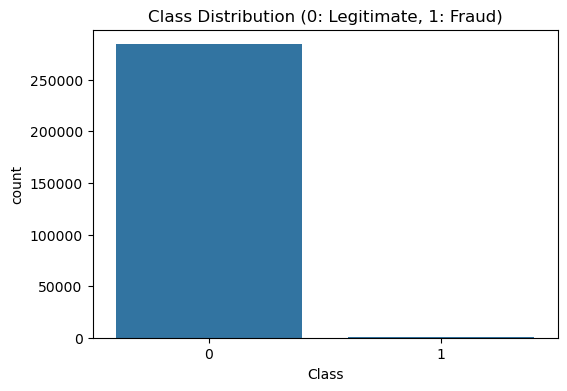

In [5]:
#Check for class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Legitimate, 1: Fraud)')
plt.show()

In [6]:
#Display Class Distribution
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [32]:
#Show percentage of Fraud Class
fraud_percentage = df['Class'].value_counts(normalize=True) * 100
print(f'Fraud Cases: {fraud_percentage[1]:.4f}% of total transactions')

Fraud Cases: 0.1727% of total transactions


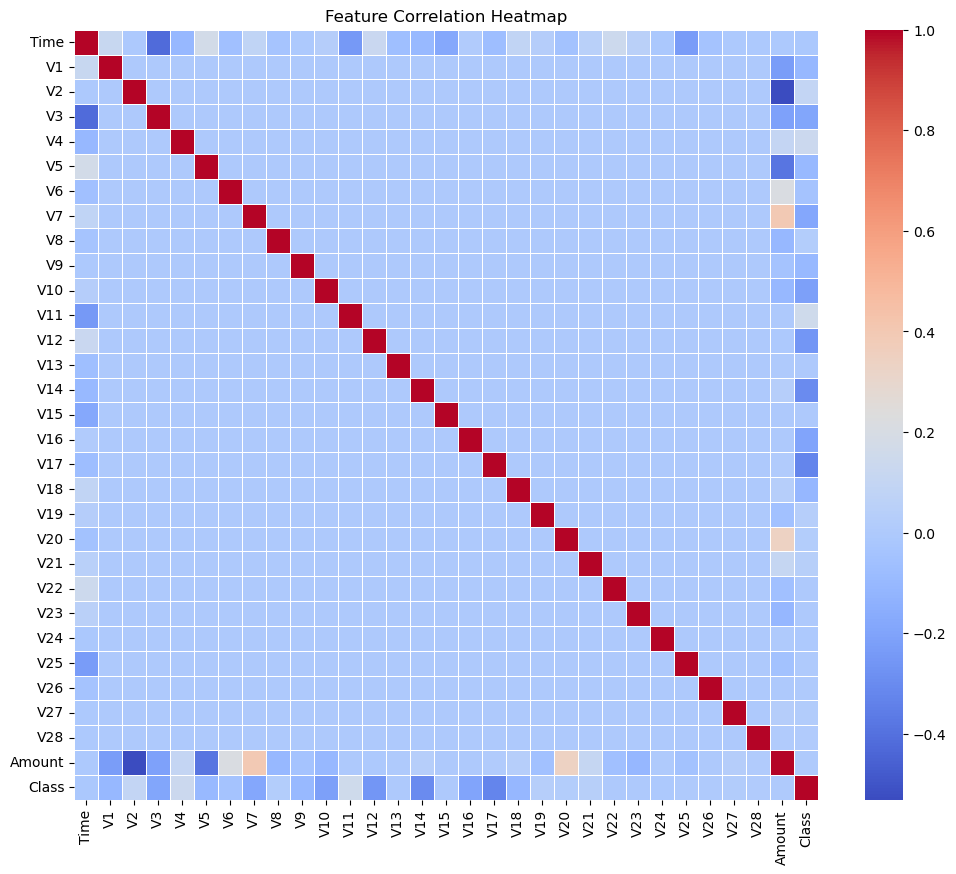

In [7]:
#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

---

## 5. Data Preprocessing

---

In [8]:
# Define features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [11]:
#Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

___

## 6. Baseline Model Training

---

In [12]:
#Train a baseline RandomForestClassifier
base_model = LogisticRegression(max_iter=10000, random_state=42)
base_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [33]:
#Predictions
y_pred_base = base_model.predict(X_test_scaled)
y_pred_prob_base = base_model.predict_proba(X_test_scaled)[:,1]

In [14]:
#Evaluate the model
print('Baseline Model Performance:\n', classification_report(y_test, y_pred_base))

Baseline Model Performance:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Handling Imbalance using SMOTE

---

In [34]:
#Apply SMOTE
smote = SMOTE(sampling_strategy='auto',random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [16]:
#Train model on SMOTE data
model_smote = LogisticRegression(max_iter=10000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=10000, random_state=42)

In [18]:
#Predictions
y_pred_smote = model_smote.predict(X_test_scaled)
y_pred_prob_smote = model_smote.predict_proba(X_test_scaled)[:,1]

In [35]:
#Evaluate Performance
print('SMOTE Model Performance:\n', classification_report(y_test, y_pred_smote))

SMOTE Model Performance:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



---

## 8. Weighted Loss Functions

---

In [36]:
#Train Logistic Regression with class_weight='balanced'
weighted_model = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
weighted_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)

In [38]:
#Predictions
y_pred_weighted = weighted_model.predict(X_test_scaled)
y_pred_prob_weighted = weighted_model.predict_proba(X_test_scaled)[:,1]

In [40]:
#Evaluate Performance
print('Model Performance with weighted Loss Function:\n', classification_report(y_test, y_pred_weighted))

Model Performance with weighted Loss Function:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



## 9. Visualization of Results

---

In [41]:
#Confusion Matrices

def plot_confusion_matrix(y_true, y_pred, title):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, cmap='Blues',fmt='d', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

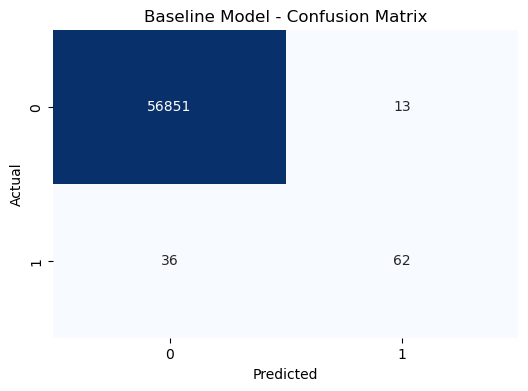

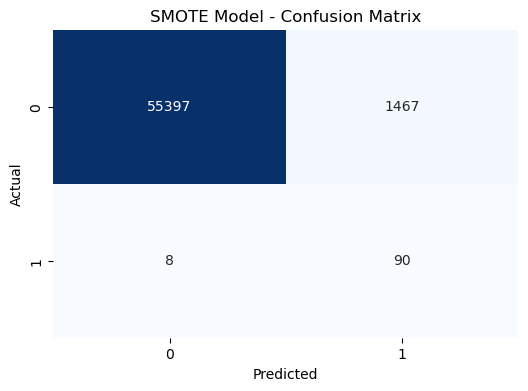

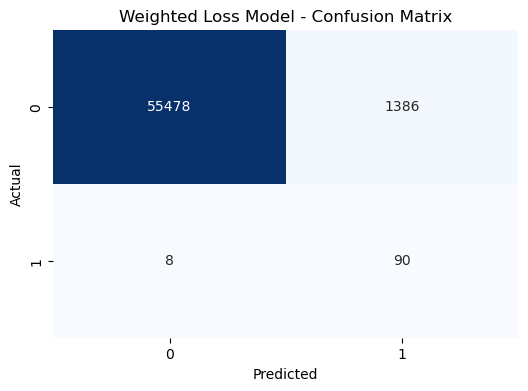

In [42]:
#Plot confusion matrices
plot_confusion_matrix(y_test, y_pred_base, 'Baseline Model - Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_smote, 'SMOTE Model - Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_weighted, 'Weighted Loss Model - Confusion Matrix')

In [46]:
#ROC Curve
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_prob_base)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_pred_prob_smote)
fpr_weighted, tpr_weighted, _ = roc_curve(y_test, y_pred_prob_weighted)

In [28]:
print(y_pred_prob_smote.shape)

(56962,)


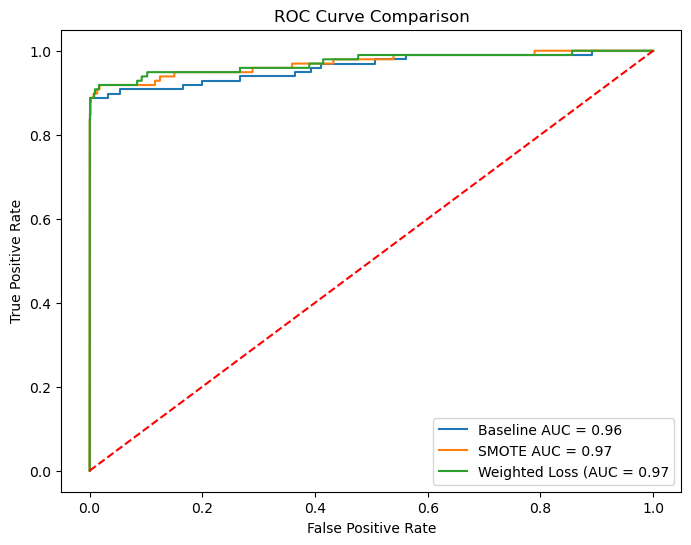

In [47]:
#Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr_base, tpr_base, label=f'Baseline AUC = {roc_auc_score(y_test, y_pred_prob_base):.2f}')
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE AUC = {roc_auc_score(y_test, y_pred_prob_smote):.2f}')
plt.plot(fpr_weighted, tpr_weighted, label=f'Weighted Loss (AUC = {roc_auc_score(y_test, y_pred_prob_weighted):.2f}')

plt.plot([0,1],[0,1], linestyle='--', color='r')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

---

## 10. Conclusion

- **SMOTE** effectively balances the dataset by generating synthetic minority samples.
- **Weighted Loss Functions** adjust model training to give more importance to the minority class.
- **Both techniques significantly improved fraud detection.**

This concludes **Day 33** of our Machine Learning journey! 🚀